# TCN Forecasting for CPI MoM Inflation

Clean Temporal Convolutional Network version equivalent to the GRU/LSTM notebooks.

Model setup:
- Target: `cpi_mom_inflation`
- Inputs: exogenous variables only by default
- Optional ARX-TCN: use lagged target + exogenous variables
- Window: 12 months
- Horizon: 1 month ahead
- Split: chronological train/validation/test
- Benchmark: Random Walk

In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, SpatialDropout1D,
    Add, Activation, Lambda, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.style.use("seaborn-v0_8-darkgrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step8_tcn")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
target_var = "cpi_mom_inflation"
exog_vars = [
    "broad_money", "ppi_qoq", "wti", "gold",
    "policy_rate", "VNINDEX", "NIKKEI225", "USDVND"
]

df_raw = pd.read_csv(
    os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv"),
    index_col=0,
    parse_dates=True
)

df_all = df_raw[[target_var] + exog_vars].copy().dropna()

print(f"Raw data shape: {df_all.shape}")
print(f"Period: {df_all.index.min().date()} to {df_all.index.max().date()}")

Raw data shape: (360, 9)
Period: 1995-01-01 to 2024-12-01


In [3]:
def classify_stationarity(series):
    s = pd.Series(series).dropna()
    adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    return "I(0)" if adf_p < 0.05 else "I(1)"

transformed, name_map = {}, {}

for col in df_all.columns:
    status = classify_stationarity(df_all[col])

    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_all[col]
    else:
        if col == "policy_rate" or (df_all[col] <= 0).any():
            new_col = f"diff_{col}"
            transformed[new_col] = df_all[col].diff()
        else:
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_all[col]).diff()

    name_map[col] = new_col

df = pd.DataFrame(transformed, index=df_all.index).dropna()

target_col = name_map[target_var]

# Option A: exogenous variables only, same as current GRU version
feature_cols = [c for c in df.columns if c != target_col]

# Option B: ARX-TCN, use lagged inflation + exogenous variables
# feature_cols = list(df.columns)

print(f"Data shape: {df.shape}")
print(f"Target after transform: {target_col}")
print(f"Target included in features: {target_col in feature_cols}")
print(f"Feature columns: {feature_cols}")

Data shape: (359, 9)
Target after transform: cpi_mom_inflation
Target included in features: False
Feature columns: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']


In [4]:
def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []
    values_X = df[feature_cols].values
    values_y = df[target_col].values
    index = df.index

    for i in range(window, len(df) - horizon + 1):
        X.append(values_X[i-window:i])
        y.append(values_y[i + horizon - 1])
        dates.append(index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)

window = 12
horizon = 1

X, y, y_dates = create_supervised_sequences(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    window=window,
    horizon=horizon
)

print("Supervised sequence creation")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of features: {X.shape[2]}")
print(f"Forecast horizon: {horizon} month ahead")

print("\nLeakage check")
print(f"X end date example: {df.index[window-1].date()}")
print(f"y date example:     {df.index[window].date()}")
print("Correct if X end date is before y date.")

Supervised sequence creation
X shape: (347, 12, 8)
y shape: (347,)
Number of features: 8
Forecast horizon: 1 month ahead

Leakage check
X end date example: 1996-01-01
y date example:     1996-02-01
Correct if X end date is before y date.


In [5]:
n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

print("Time-based split")
print(f"Train: X={X_train.shape}, y={y_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")

Time-based split
Train: X=(242, 12, 8), y=(242,), 1996-02-01 to 2016-03-01
Val:   X=(35, 12, 8), y=(35,), 2016-04-01 to 2019-02-01
Test:  X=(70, 12, 8), y=(70,), 2019-03-01 to 2024-12-01


In [6]:
n_train, p, d = X_train.shape

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("Scaling completed")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaling completed
X_train_scaled: (242, 12, 8)
X_val_scaled:   (35, 12, 8)
X_test_scaled:  (70, 12, 8)


In [7]:
def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout=0.15):
    shortcut = x

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal",
        kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
    )(x)
    x = LayerNormalization()(x)
    x = Activation("relu")(x)
    x = SpatialDropout1D(dropout)(x)

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal",
        kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
    )(x)
    x = LayerNormalization()(x)
    x = Activation("relu")(x)
    x = SpatialDropout1D(dropout)(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters=filters, kernel_size=1, padding="same")(shortcut)

    x = Add()([shortcut, x])
    x = Activation("relu")(x)
    return x


def build_tcn(window, n_features, filters=32, kernel_size=3, dilations=(1, 2, 4), dropout=0.15, lr=0.001):
    inputs = Input(shape=(window, n_features))
    x = inputs

    for dilation in dilations:
        x = residual_tcn_block(
            x=x,
            filters=filters,
            kernel_size=kernel_size,
            dilation_rate=dilation,
            dropout=dropout
        )

    # Use the last time step because causal convolutions make it depend only on past inputs.
    x = Lambda(lambda z: z[:, -1, :])(x)
    x = Dense(32, activation="relu", kernel_regularizer=L1L2(l1=5e-6, l2=1e-5))(x)
    x = Dropout(dropout * 0.5)(x)
    outputs = Dense(1)(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model

model = build_tcn(
    window=window,
    n_features=len(feature_cols),
    filters=32,
    kernel_size=3,
    dilations=(1, 2, 4),
    dropout=0.15,
    lr=0.001
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 12, 32)    │        800 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 32)    │         64 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 12, 32)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 12, 32)    │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 32)    │      3,104 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 32)    │         64 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 12, 32)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 32)    │        288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 12, 32)    │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 32)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 12, 32)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 32)    │      3,104 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 32)    │         64 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 12, 32)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 12, 32)    │          0 │ activation_3[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 12, 32)    │      3,104 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 32)    │         64 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 18,081 (70.63 KB)

 Trainable params: 18,081 (70.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=16,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val loss:   {history.history['val_loss'][-1]:.6f}")

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 1.4979 - mae: 0.9698 - val_loss: 0.6424 - val_mae: 0.6926 - learning_rate: 0.0010
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2499 - mae: 0.8245 - val_loss: 0.2325 - val_mae: 0.3989 - learning_rate: 0.0010
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0364 - mae: 0.7629 - val_loss: 0.2846 - val_mae: 0.4380 - learning_rate: 0.0010
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0117 - mae: 0.7500 - val_loss: 0.2084 - val_mae: 0.3598 - learning_rate: 0.0010
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9955 - mae: 0.7530 - val_loss: 0.2442 - val_mae: 0.3957 - learning_rate: 0.0010
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8671 - mae: 0.7028 - val_loss: 0.2454 - val_mae: 0.3974 - learning_rate: 0.0010
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8694 - mae: 0.6895 - val_loss: 0.2273 - val_mae: 0.3913 - learning_rate: 0.0010
Epoch 8/200


In [9]:
y_pred_scaled = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

# Random Walk benchmark: forecast y_t by y_{t-1}
y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

print("\nTCN Test Results")
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")


TCN Test Results
R²:                 -0.2371
RMSE:               0.524117
MAE:                0.404404
Random Walk RMSE:   0.564010
Random Walk MAE:    0.419571
Model / RW RMSE:    0.9293


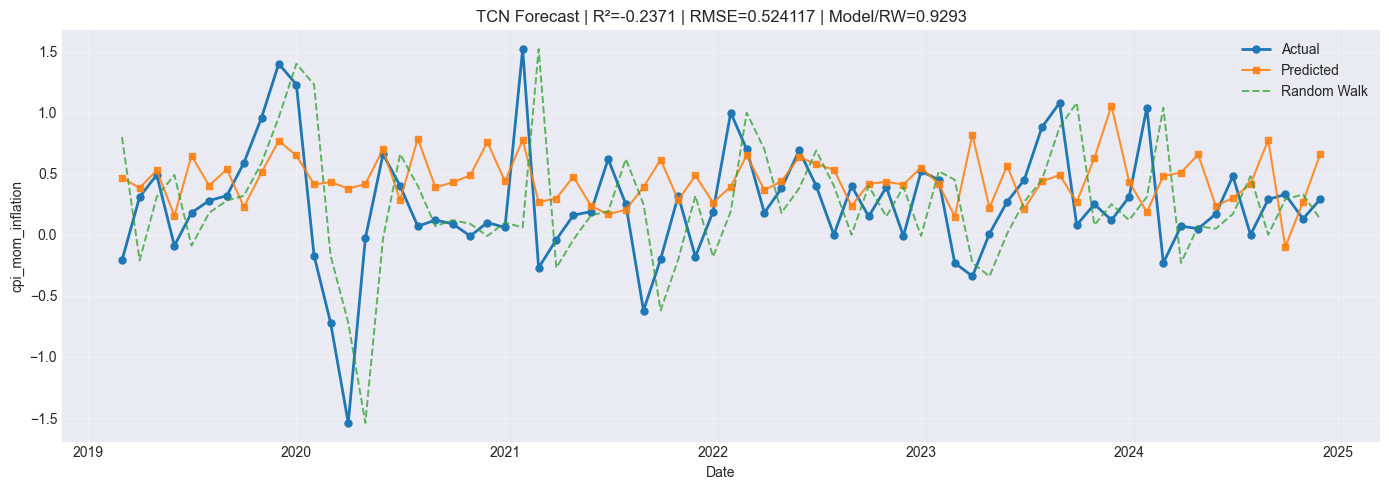

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.5, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)

ax.set_title(f"TCN Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tcn_forecast.png"), dpi=150)
plt.show()

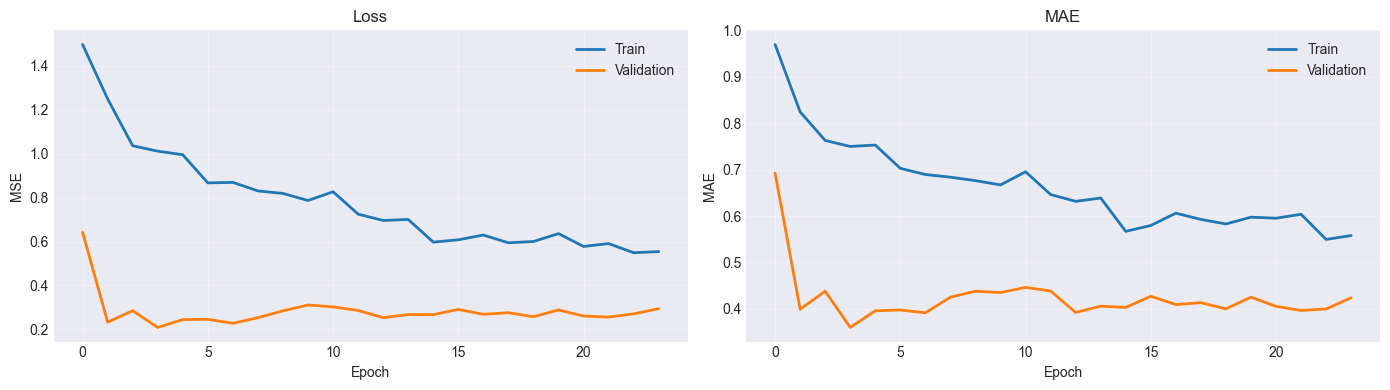

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history["loss"], label="Train", linewidth=2)
ax1.plot(history.history["val_loss"], label="Validation", linewidth=2)
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train", linewidth=2)
ax2.plot(history.history["val_mae"], label="Validation", linewidth=2)
ax2.set_title("MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tcn_training.png"), dpi=150)
plt.show()

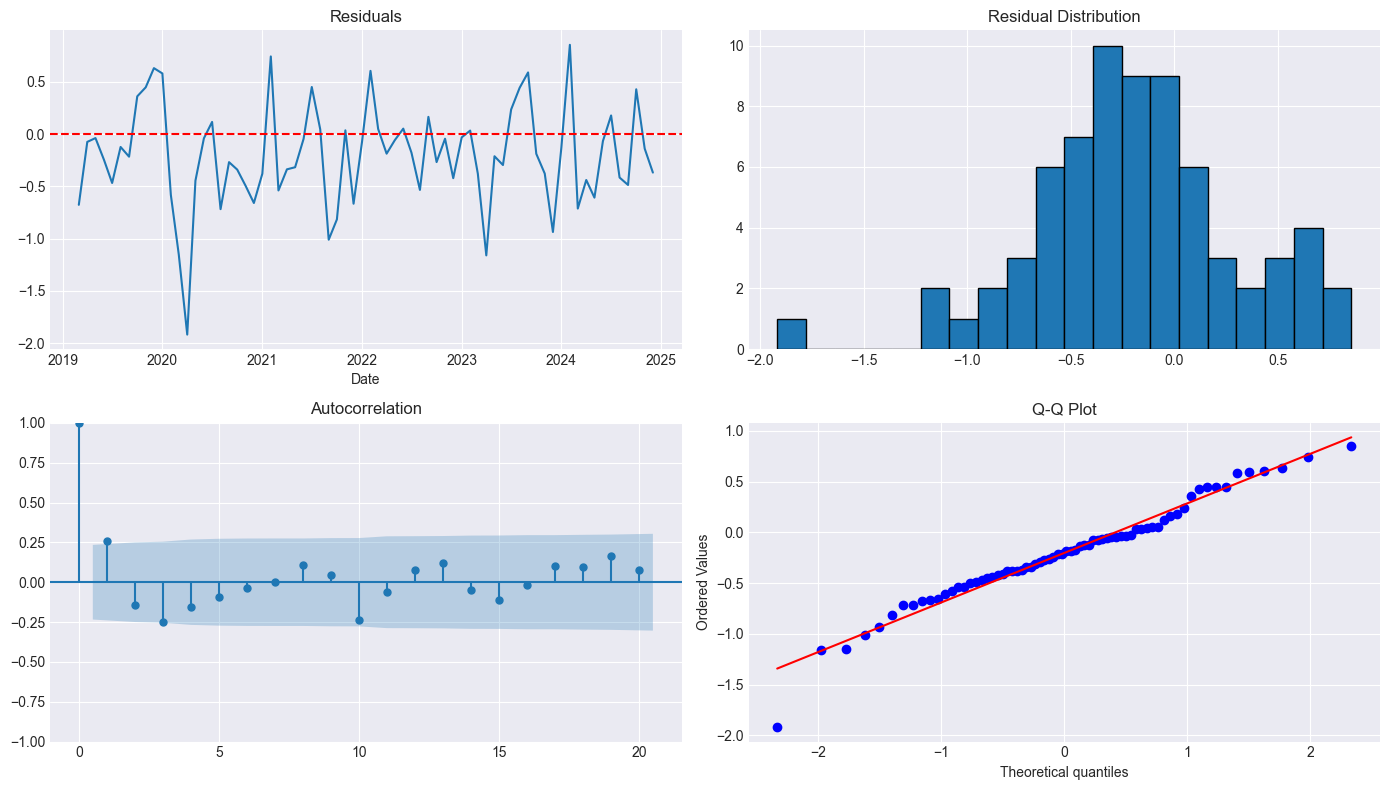

Residual diagnostics
Residual mean: -0.202780
Residual std:  0.483300
Jarque-Bera p-value: 0.043207


In [12]:
residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tcn_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print("Residual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

Improved ARX-TCN setup
Target column: cpi_mom_inflation
Target included in features: True
Number of features: 9
Features: ['cpi_mom_inflation', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']

Sequence creation
X shape: (347, 12, 9)
y shape: (347,)

Leakage check
X end date example: 1996-01-01
y date example:     1996-02-01
Correct if X end date is before y date.

Time split
Train: (242, 12, 9), 1996-02-01 to 2016-03-01
Val:   (35, 12, 9), 2016-04-01 to 2019-02-01
Test:  (70, 12, 9), 2019-03-01 to 2024-12-01


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 12, 16)    │        448 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 16)    │         32 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 12, 16)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 12, 16)    │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 12, 16)    │        784 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 16)    │         32 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 12, 16)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 16)    │        160 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 12, 16)    │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 16)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 12, 16)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 12, 16)    │        784 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 16)    │         32 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 12, 16)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 12, 16)    │          0 │ activation_3[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 12, 16)    │        784 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 16)    │         32 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,377 (13.19 KB)

 Trainable params: 3,377 (13.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.7084 - mae: 1.0960 - val_loss: 0.2263 - val_mae: 0.5494 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5794 - mae: 0.9353 - val_loss: 0.2103 - val_mae: 0.5260 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5110 - mae: 0.8736 - val_loss: 0.2137 - val_mae: 0.5251 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4725 - mae: 0.8150 - val_loss: 0.1893 - val_mae: 0.4841 - learning_rate: 5.0000e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4046 - mae: 0.7409 - val_loss: 0.1721 - val_mae: 0.4555 - learning_rate: 5.0000e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4515 - mae: 0.8012 - val_loss: 0.1602 - val_mae: 0.4376 - learning_rate: 5.0000e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4276 - mae: 0.7483 - val_loss: 0.1552 - val_mae: 0.4334 - learning_r

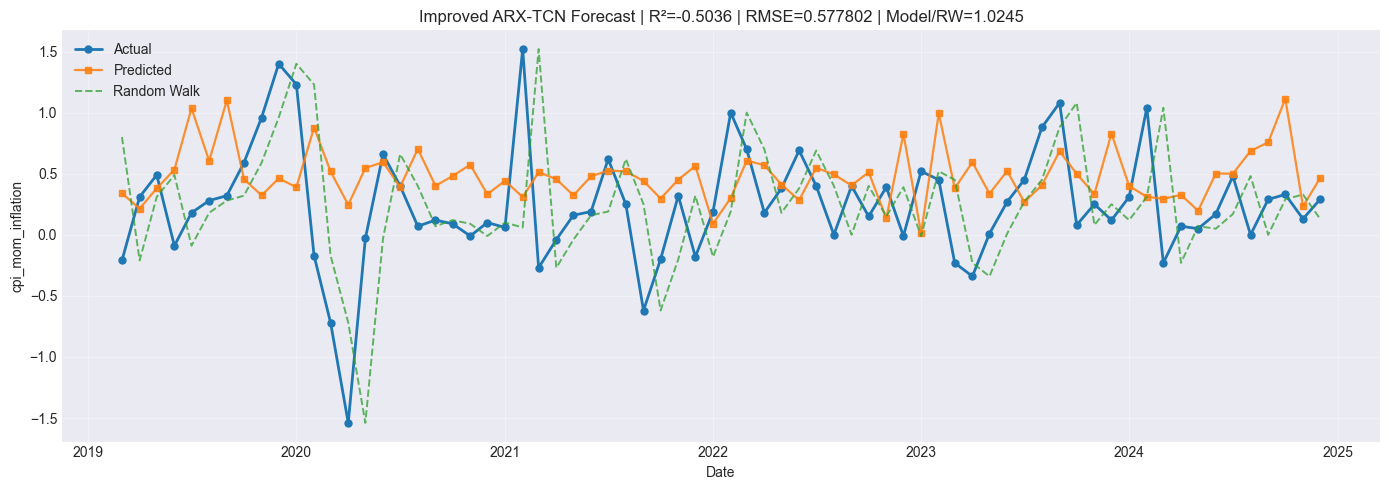

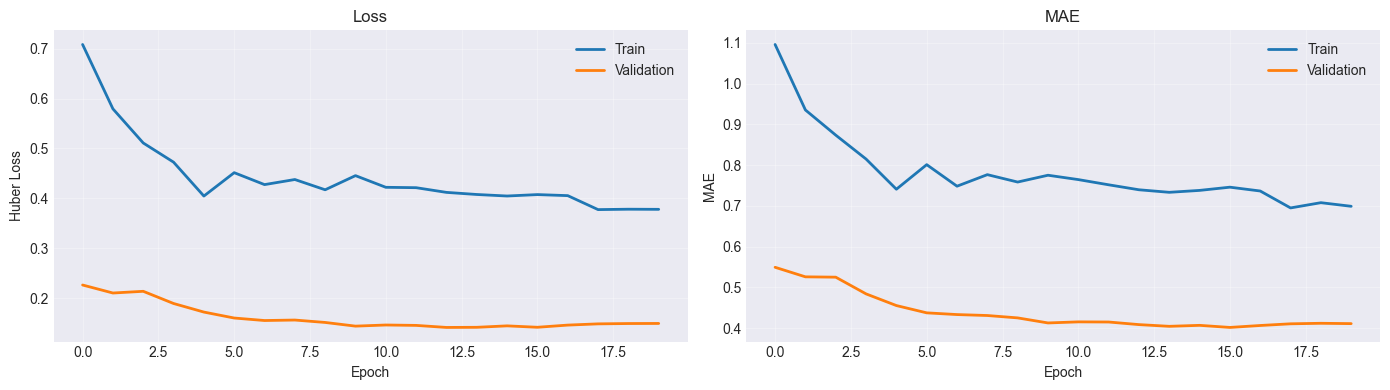

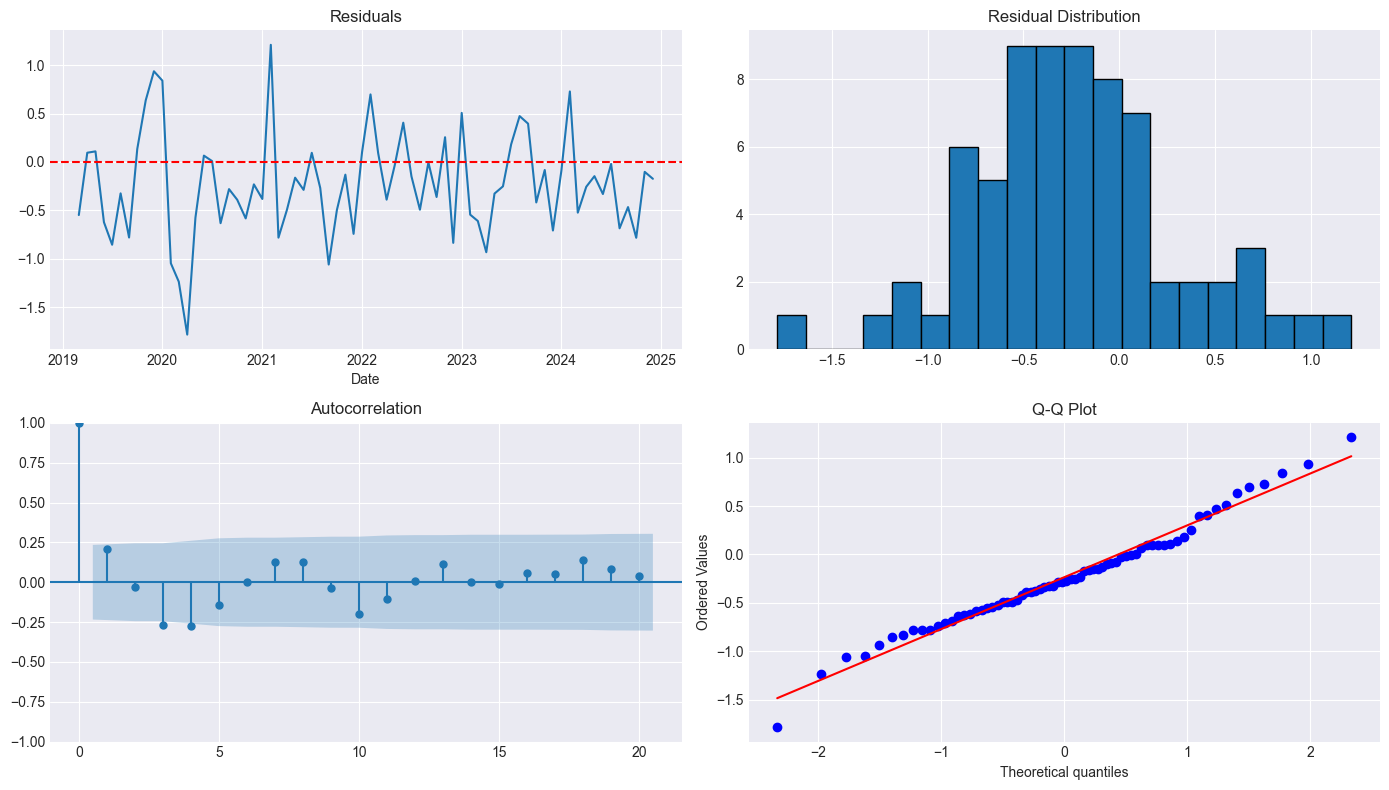


Residual diagnostics
Residual mean: -0.235190
Residual std:  0.527770
Jarque-Bera p-value: 0.438199


In [13]:
# ============================================================
# Improved ARX-TCN: lagged inflation + exogenous variables
# ============================================================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, SpatialDropout1D,
    Add, Activation, Lambda, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

from scipy.stats import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# -----------------------------
# 1. Reproducibility
# -----------------------------
SEED = 42
tf.keras.backend.clear_session()
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR_TCN = os.path.join(os.getcwd(), "outputs", "step8_tcn_improved")
os.makedirs(OUTPUT_DIR_TCN, exist_ok=True)

# -----------------------------
# 2. Configuration
# -----------------------------
window = 12
horizon = 1

# Include inflation as lagged autoregressive feature.
# Safe because X uses only past observations: t-12 ... t-1.
feature_cols_tcn = list(df.columns)

print("Improved ARX-TCN setup")
print(f"Target column: {target_col}")
print(f"Target included in features: {target_col in feature_cols_tcn}")
print(f"Number of features: {len(feature_cols_tcn)}")
print(f"Features: {feature_cols_tcn}")

# -----------------------------
# 3. Create supervised sequences
# -----------------------------
def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []

    for i in range(window, len(df) - horizon + 1):
        X.append(df[feature_cols].iloc[i-window:i].values)
        y.append(df[target_col].iloc[i + horizon - 1])
        dates.append(df.index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)


X, y, y_dates = create_supervised_sequences(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols_tcn,
    window=window,
    horizon=horizon
)

print("\nSequence creation")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nLeakage check")
print(f"X end date example: {df.index[window-1].date()}")
print(f"y date example:     {df.index[window].date()}")
print("Correct if X end date is before y date.")

# -----------------------------
# 4. Time-based split
# -----------------------------
n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

print("\nTime split")
print(f"Train: {X_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   {X_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  {X_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")

# -----------------------------
# 5. Scaling
# -----------------------------
n_train, p, d = X_train.shape

x_scaler = RobustScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

# -----------------------------
# 6. Improved TCN block
# -----------------------------
def residual_tcn_block(
    x,
    filters=16,
    kernel_size=3,
    dilation_rate=1,
    dropout=0.25,
    l1=1e-5,
    l2=1e-4
):
    shortcut = x

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal",
        kernel_regularizer=L1L2(l1=l1, l2=l2)
    )(x)
    x = LayerNormalization()(x)
    x = Activation("relu")(x)
    x = SpatialDropout1D(dropout)(x)

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal",
        kernel_regularizer=L1L2(l1=l1, l2=l2)
    )(x)
    x = LayerNormalization()(x)
    x = Activation("relu")(x)
    x = SpatialDropout1D(dropout)(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
            kernel_regularizer=L1L2(l1=l1, l2=l2)
        )(shortcut)

    x = Add()([shortcut, x])
    x = Activation("relu")(x)

    return x


def build_improved_tcn(
    window,
    n_features,
    filters=16,
    kernel_size=3,
    dilations=(1, 2),
    dropout=0.25,
    lr=0.0005
):
    inputs = Input(shape=(window, n_features))
    x = inputs

    for dilation in dilations:
        x = residual_tcn_block(
            x=x,
            filters=filters,
            kernel_size=kernel_size,
            dilation_rate=dilation,
            dropout=dropout,
            l1=1e-5,
            l2=1e-4
        )

    # Use the final causal time step to forecast next month.
    x = Lambda(lambda z: z[:, -1, :])(x)

    x = Dense(
        16,
        activation="relu",
        kernel_regularizer=L1L2(l1=1e-5, l2=1e-4)
    )(x)
    x = Dropout(0.15)(x)

    outputs = Dense(1)(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


model_tcn = build_improved_tcn(
    window=window,
    n_features=len(feature_cols_tcn),
    filters=16,
    kernel_size=3,
    dilations=(1, 2),
    dropout=0.25,
    lr=0.0005
)

model_tcn.summary()

# -----------------------------
# 7. Train
# -----------------------------
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_tcn = model_tcn.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=8,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# 8. Prediction and evaluation
# -----------------------------
y_pred_scaled = model_tcn.predict(X_test_scaled, verbose=0).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

# Random Walk benchmark
y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

# Mean baseline
y_mean = np.repeat(np.mean(y_test_actual), len(y_test_actual))
rmse_mean = np.sqrt(mean_squared_error(y_test_actual, y_mean))
mae_mean = mean_absolute_error(y_test_actual, y_mean)
vs_mean = rmse / rmse_mean if rmse_mean > 0 else np.nan

print("\n" + "="*80)
print("IMPROVED ARX-TCN TEST RESULTS")
print("="*80)
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")
print(f"Mean Baseline RMSE: {rmse_mean:.6f}")
print(f"Mean Baseline MAE:  {mae_mean:.6f}")
print(f"Model / Mean RMSE:  {vs_mean:.4f}")
print("="*80)

if vs_rw < 1:
    print("Interpretation: Improved ARX-TCN beats Random Walk by RMSE.")
else:
    print("Interpretation: Improved ARX-TCN does not beat Random Walk by RMSE.")

if vs_mean < 1:
    print("Interpretation: Improved ARX-TCN beats Mean baseline, so R² should be positive.")
else:
    print("Interpretation: Improved ARX-TCN does not beat Mean baseline, so R² can be negative.")

# -----------------------------
# 9. Prediction diagnostics
# -----------------------------
print("\nPrediction diagnostics")
print(f"Actual mean: {np.mean(y_test_actual):.6f}")
print(f"Pred mean:   {np.mean(y_pred):.6f}")
print(f"Actual std:  {np.std(y_test_actual):.6f}")
print(f"Pred std:    {np.std(y_pred):.6f}")
print(f"Actual min:  {np.min(y_test_actual):.6f}")
print(f"Actual max:  {np.max(y_test_actual):.6f}")
print(f"Pred min:    {np.min(y_pred):.6f}")
print(f"Pred max:    {np.max(y_pred):.6f}")

# -----------------------------
# 10. Forecast plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.6, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)

ax.set_title(
    f"Improved ARX-TCN Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}"
)
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_TCN, "improved_arx_tcn_forecast.png"), dpi=150)
plt.show()

# -----------------------------
# 11. Training curve
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_tcn.history["loss"], label="Train", linewidth=2)
axes[0].plot(history_tcn.history["val_loss"], label="Validation", linewidth=2)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_tcn.history["mae"], label="Train", linewidth=2)
axes[1].plot(history_tcn.history["val_mae"], label="Validation", linewidth=2)
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_TCN, "improved_arx_tcn_training.png"), dpi=150)
plt.show()

# -----------------------------
# 12. Residual diagnostics
# -----------------------------
residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_TCN, "improved_arx_tcn_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print("\nResidual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

Target: cpi_mom_inflation
Exogenous columns: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']

Feature frame shape: (347, 45)
Volatility threshold: 0.780709
Sequential features: 14
Tabular stacking features: 36
SARIMAX exog features: 12

Sequence shape: (335, 12, 14)
Target shape: (335,)
Dates: 1997-02-01 to 2024-12-01

Time split
Train: (234, 12, 14), 1997-02-01 to 2016-07-01
Val:   (34, 12, 14), 2016-08-01 to 2019-05-01
Test:  (67, 12, 14), 2019-06-01 to 2024-12-01

SARIMAX branch completed
SARIMAX val RMSE:  0.574596
SARIMAX test RMSE: 0.655735
Epoch 1/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.5455 - mae: 0.9309 - val_loss: 0.5797 - val_mae: 1.0257 - learning_rate: 7.0000e-04
Epoch 2/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3997 - mae: 0.7469 - val_loss: 0.2011 - val_mae: 0.5096 - learning_rate: 7.0000e-04
Epoch 3/250
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3482 - mae: 

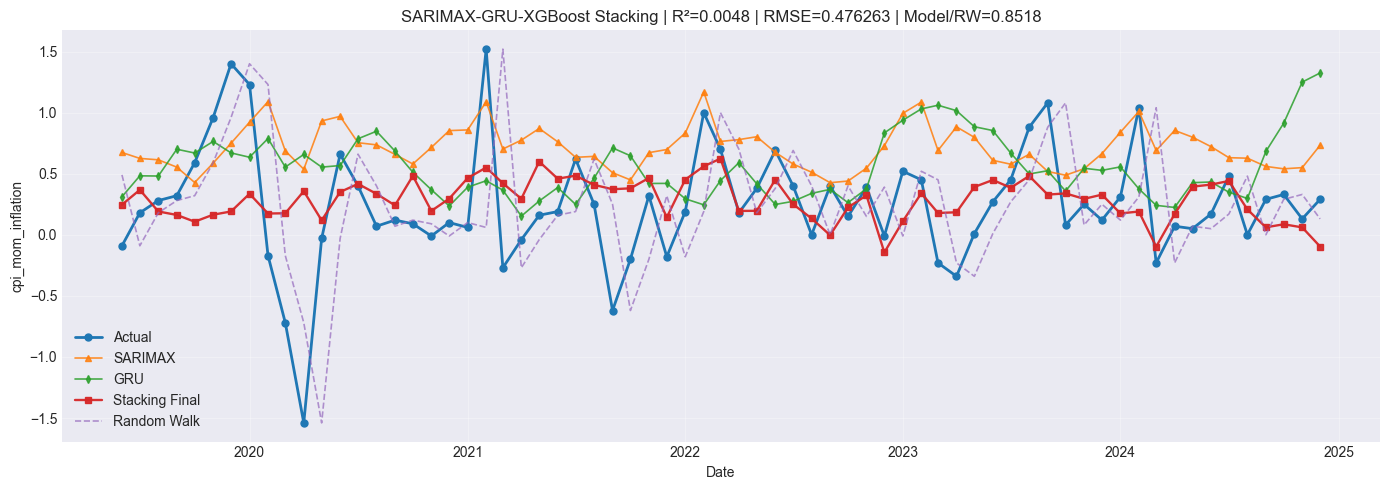

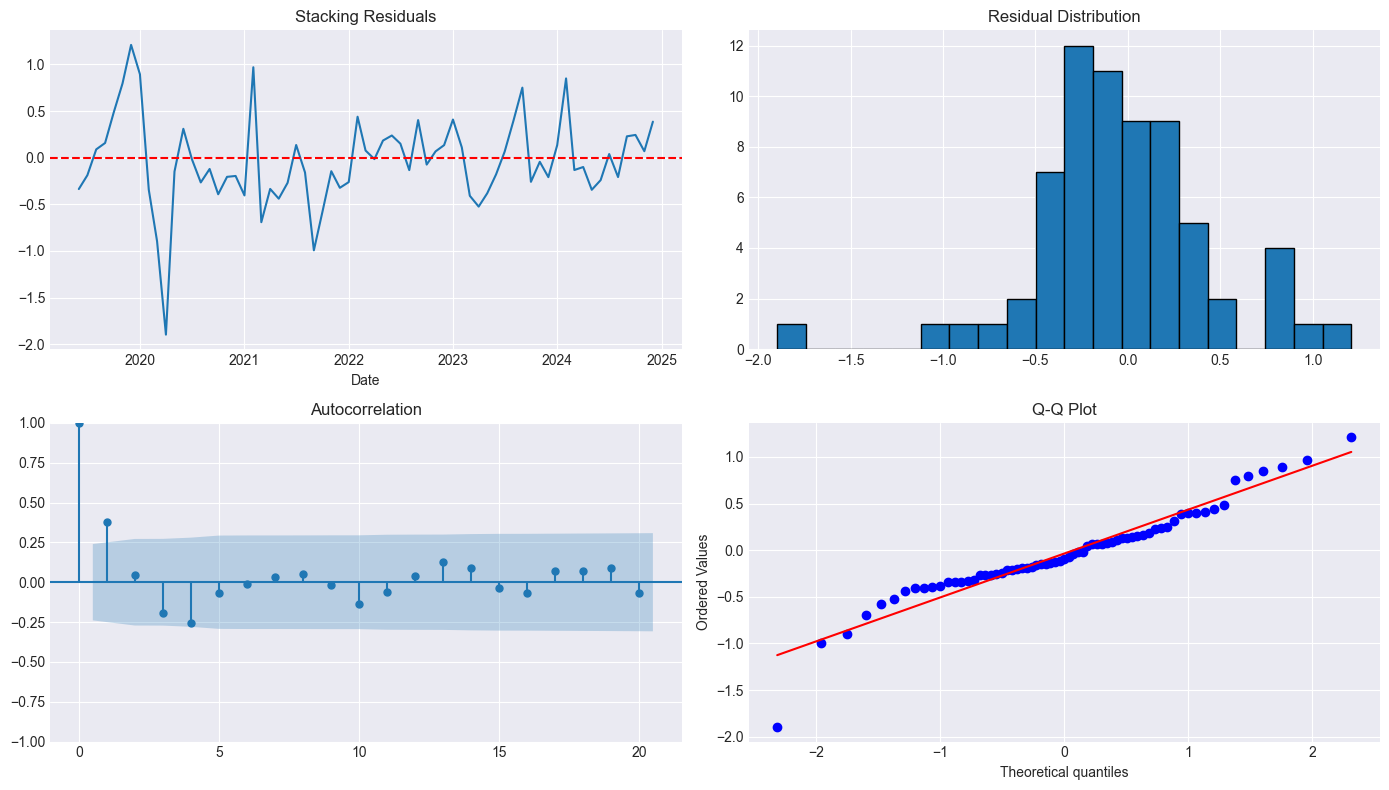


Residual diagnostics
Residual mean: -0.036303
Residual std:  0.474877
Jarque-Bera p-value: 0.000007

Top 20 stacking meta-features
                         feature  importance
50          dlog_wti_roll_mean_3    0.071152
18                 gru_hidden_14    0.065345
49      diff_ppi_qoq_roll_mean_3    0.064280
28        cpi_mom_inflation_lag2    0.059417
34                 dlog_wti_lag1    0.056804
39              dlog_USDVND_lag1    0.049775
41             diff_ppi_qoq_lag2    0.046891
2          pred_diff_sarimax_gru    0.042442
17                 gru_hidden_13    0.040449
30        cpi_mom_inflation_lag6    0.038310
9                   gru_hidden_5    0.038160
0                   sarimax_pred    0.031076
4                   gru_hidden_0    0.029729
10                  gru_hidden_6    0.028562
27        cpi_mom_inflation_lag1    0.023880
33             diff_ppi_qoq_lag1    0.023448
24  cpi_mom_inflation_roll_std_6    0.020906
29        cpi_mom_inflation_lag3    0.019401
47           

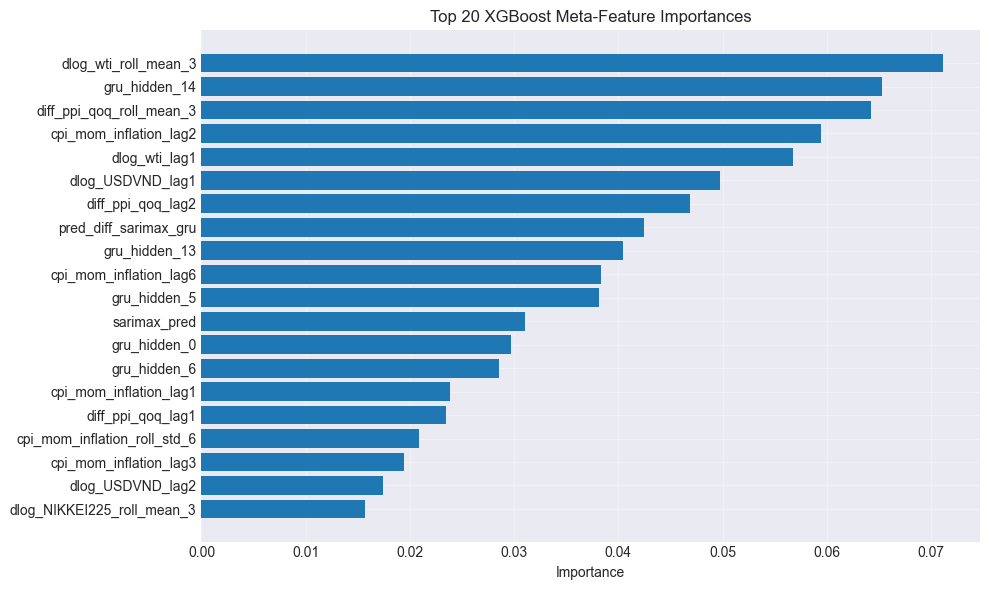


SARIMAX-GRU-XGBOOST STACKING SUMMARY
Model: SARIMAX-GRU-XGBoost Stacking
Target: cpi_mom_inflation
SARIMAX order: (1, 0, 2)
SARIMAX seasonal order: (1, 0, 1, 12)
GRU input shape: (12, 14)
Meta learner: XGBRegressor
Meta features: 56
Train samples: 234
Validation samples used for meta-learning: 34
Test samples: 67
Final R²: 0.0048
Final RMSE: 0.476263
Final MAE: 0.347449
Model / Random Walk RMSE: 0.8518
Model / Mean RMSE: 0.9976


In [14]:
# ============================================================
# SARIMAX-GRU-XGBoost Stacking Hybrid
# Final forecast = XGBoost(SARIMAX forecast, GRU forecast, GRU hidden state, engineered features)
# ============================================================

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("xgboost is not installed. Fallback: HistGradientBoostingRegressor")

# Fix compatibility issue if needed
if not hasattr(np, "matrix"):
    np.matrix = np.ndarray

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step11_sarimax_gru_xgb_stacking")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "SARIMAX-GRU-XGBoost Stacking"
MODEL_TAG = "sarimax_gru_xgb_stacking"

# ------------------------------------------------------------
# 1. Identify exogenous transformed columns
# ------------------------------------------------------------
try:
    exog_cols = exog_transformed_cols
except NameError:
    exog_cols = [c for c in df.columns if c != target_col]

print("Target:", target_col)
print("Exogenous columns:", exog_cols)

# ------------------------------------------------------------
# 2. Feature engineering
# ------------------------------------------------------------
def build_feature_frame(df, target_col, exog_cols):
    out = df.copy()

    # Month seasonality
    month = out.index.month.values
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)

    # Target lags
    for lag in [1, 2, 3, 6, 12]:
        out[f"{target_col}_lag{lag}"] = out[target_col].shift(lag)

    # Target rolling features, shifted to avoid leakage
    out[f"{target_col}_roll_mean_3"] = out[target_col].rolling(3).mean().shift(1)
    out[f"{target_col}_roll_mean_6"] = out[target_col].rolling(6).mean().shift(1)
    out[f"{target_col}_roll_std_6"] = out[target_col].rolling(6).std().shift(1)
    out[f"{target_col}_roll_std_12"] = out[target_col].rolling(12).std().shift(1)

    # Regime feature
    vol_col = f"{target_col}_roll_std_12"
    threshold = out[vol_col].quantile(0.75)
    out["high_vol_regime"] = (out[vol_col] > threshold).astype(float)

    # Exogenous lag features
    for col in exog_cols:
        out[f"{col}_lag1"] = out[col].shift(1)
        out[f"{col}_lag2"] = out[col].shift(2)
        out[f"{col}_roll_mean_3"] = out[col].rolling(3).mean().shift(1)

    return out.dropna(), threshold


df_model, vol_threshold = build_feature_frame(df, target_col, exog_cols)

# Sequential GRU features: include target + exog + engineered features in past window
seq_feature_cols = list(df.columns) + [
    "month_sin",
    "month_cos",
    f"{target_col}_roll_std_6",
    f"{target_col}_roll_std_12",
    "high_vol_regime"
]

# Tabular stacking features: only known/past engineered features
tab_feature_cols = (
    ["month_sin", "month_cos", f"{target_col}_roll_mean_3", f"{target_col}_roll_mean_6",
     f"{target_col}_roll_std_6", f"{target_col}_roll_std_12", "high_vol_regime"]
    + [f"{target_col}_lag{lag}" for lag in [1, 2, 3, 6, 12]]
    + [f"{col}_lag1" for col in exog_cols]
    + [f"{col}_lag2" for col in exog_cols]
    + [f"{col}_roll_mean_3" for col in exog_cols]
)

sarimax_exog_cols = (
    [f"{col}_lag1" for col in exog_cols]
    + ["month_sin", "month_cos", f"{target_col}_roll_std_12", "high_vol_regime"]
)

print("\nFeature frame shape:", df_model.shape)
print("Volatility threshold:", round(vol_threshold, 6))
print("Sequential features:", len(seq_feature_cols))
print("Tabular stacking features:", len(tab_feature_cols))
print("SARIMAX exog features:", len(sarimax_exog_cols))

# ------------------------------------------------------------
# 3. Create supervised sequence for GRU
# ------------------------------------------------------------
def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []

    for i in range(window, len(df) - horizon + 1):
        X.append(df[feature_cols].iloc[i-window:i].values)
        y.append(df[target_col].iloc[i + horizon - 1])
        dates.append(df.index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)


window = 12
horizon = 1

X_seq, y, y_dates = create_supervised_sequences(
    df=df_model,
    target_col=target_col,
    feature_cols=seq_feature_cols,
    window=window,
    horizon=horizon
)

tab_features_all = df_model.loc[y_dates, tab_feature_cols]
sarimax_exog_all = df_model.loc[y_dates, sarimax_exog_cols]

print("\nSequence shape:", X_seq.shape)
print("Target shape:", y.shape)
print("Dates:", y_dates.min().date(), "to", y_dates.max().date())

# ------------------------------------------------------------
# 4. Time split
# ------------------------------------------------------------
n = len(X_seq)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X_seq[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X_seq[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X_seq[val_end:], y[val_end:], y_dates[val_end:]

tab_train = tab_features_all.iloc[:train_end]
tab_val = tab_features_all.iloc[train_end:val_end]
tab_test = tab_features_all.iloc[val_end:]

sarimax_exog_train = sarimax_exog_all.iloc[:train_end]
sarimax_exog_val = sarimax_exog_all.iloc[train_end:val_end]
sarimax_exog_test = sarimax_exog_all.iloc[val_end:]

print("\nTime split")
print(f"Train: {X_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   {X_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  {X_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")

# ------------------------------------------------------------
# 5. Scale sequence data for GRU
# ------------------------------------------------------------
n_train, p, d = X_train.shape

x_scaler = RobustScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

# ------------------------------------------------------------
# 6. Train SARIMAX branch
# ------------------------------------------------------------
SARIMAX_ORDER = (1, 0, 2)
SARIMAX_SEASONAL_ORDER = (1, 0, 1, 12)

sarimax_model = SARIMAX(
    pd.Series(y_train, index=dates_train),
    exog=sarimax_exog_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend="c"
)

sarimax_res = sarimax_model.fit(disp=False, maxiter=500)

# Forecast val + test together to preserve forecast path
sarimax_exog_oos = pd.concat([sarimax_exog_val, sarimax_exog_test], axis=0)
sarimax_oos_pred = sarimax_res.get_forecast(
    steps=len(sarimax_exog_oos),
    exog=sarimax_exog_oos
).predicted_mean

sarimax_oos_pred.index = sarimax_exog_oos.index
sarimax_val_pred = sarimax_oos_pred.loc[dates_val].values
sarimax_test_pred = sarimax_oos_pred.loc[dates_test].values

print("\nSARIMAX branch completed")
print(f"SARIMAX val RMSE:  {np.sqrt(mean_squared_error(y_val, sarimax_val_pred)):.6f}")
print(f"SARIMAX test RMSE: {np.sqrt(mean_squared_error(y_test, sarimax_test_pred)):.6f}")

# ------------------------------------------------------------
# 7. Train GRU branch
# ------------------------------------------------------------
def build_gru_feature_model(window, n_features, units=32, dropout=0.15, lr=0.0007):
    inputs = Input(shape=(window, n_features))

    x = GRU(
        units,
        return_sequences=True,
        kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
    )(inputs)
    x = Dropout(dropout)(x)

    x = GRU(
        units // 2,
        return_sequences=False,
        kernel_regularizer=L1L2(l1=5e-6, l2=1e-5),
        name="gru_hidden"
    )(x)

    hidden = LayerNormalization(name="hidden_state")(x)
    hidden = Dropout(dropout)(hidden)

    dense = Dense(16, activation="relu")(hidden)
    out = Dense(1, name="gru_forecast_scaled")(dense)

    model = Model(inputs, out)
    state_model = Model(inputs, [hidden, out])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=Huber(delta=1.0),
        metrics=["mae"]
    )

    return model, state_model


gru_model, gru_state_model = build_gru_feature_model(
    window=window,
    n_features=len(seq_feature_cols),
    units=32,
    dropout=0.15,
    lr=0.0007
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, min_delta=1e-4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-7, verbose=1)
]

history_gru = gru_model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=250,
    batch_size=16,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

def inverse_y(y_scaled):
    return y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).ravel()

h_train, gru_train_scaled = gru_state_model.predict(X_train_scaled, verbose=0)
h_val, gru_val_scaled = gru_state_model.predict(X_val_scaled, verbose=0)
h_test, gru_test_scaled = gru_state_model.predict(X_test_scaled, verbose=0)

gru_train_pred = inverse_y(gru_train_scaled.ravel())
gru_val_pred = inverse_y(gru_val_scaled.ravel())
gru_test_pred = inverse_y(gru_test_scaled.ravel())

print("\nGRU branch completed")
print(f"GRU val RMSE:  {np.sqrt(mean_squared_error(y_val, gru_val_pred)):.6f}")
print(f"GRU test RMSE: {np.sqrt(mean_squared_error(y_test, gru_test_pred)):.6f}")

# ------------------------------------------------------------
# 8. Build stacking features
# ------------------------------------------------------------
def build_stack_features(sarimax_pred, gru_pred, hidden_state, tab_features, prefix=""):
    base_df = tab_features.copy().reset_index(drop=True)

    pred_df = pd.DataFrame({
        "sarimax_pred": sarimax_pred,
        "gru_pred": gru_pred,
        "pred_diff_sarimax_gru": sarimax_pred - gru_pred,
        "pred_avg_sarimax_gru": 0.5 * (sarimax_pred + gru_pred)
    })

    hidden_df = pd.DataFrame(
        hidden_state,
        columns=[f"gru_hidden_{i}" for i in range(hidden_state.shape[1])]
    )

    return pd.concat([pred_df, hidden_df, base_df], axis=1)


# Honest stacking:
# Meta-learner is trained on validation predictions only, then tested on test.
X_meta_val = build_stack_features(
    sarimax_pred=sarimax_val_pred,
    gru_pred=gru_val_pred,
    hidden_state=h_val,
    tab_features=tab_val
)

X_meta_test = build_stack_features(
    sarimax_pred=sarimax_test_pred,
    gru_pred=gru_test_pred,
    hidden_state=h_test,
    tab_features=tab_test
)

meta_scaler = StandardScaler()
X_meta_val_scaled = meta_scaler.fit_transform(X_meta_val)
X_meta_test_scaled = meta_scaler.transform(X_meta_test)

print("\nMeta feature shape")
print("X_meta_val:", X_meta_val.shape)
print("X_meta_test:", X_meta_test.shape)

# ------------------------------------------------------------
# 9. Train XGBoost meta-learner
# ------------------------------------------------------------
if HAS_XGB:
    meta_model = XGBRegressor(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="reg:squarederror",
        random_state=SEED,
        reg_alpha=0.05,
        reg_lambda=1.0,
        min_child_weight=2
    )
else:
    meta_model = HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.03,
        max_leaf_nodes=7,
        l2_regularization=0.05,
        random_state=SEED
    )

meta_model.fit(X_meta_val_scaled, y_val)

stack_test_pred = meta_model.predict(X_meta_test_scaled)

print("\nMeta learner completed")
print("Meta model:", type(meta_model).__name__)

# ------------------------------------------------------------
# 10. Evaluation
# ------------------------------------------------------------
def metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Random Walk
y_rw = df_model[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test[mask], y_rw[mask])

# Mean baseline
y_mean = np.repeat(np.mean(y_test), len(y_test))
rmse_mean = np.sqrt(mean_squared_error(y_test, y_mean))
mae_mean = mean_absolute_error(y_test, y_mean)

results = [
    {"Model": "Random Walk", "RMSE": rmse_rw, "MAE": mae_rw, "R2": np.nan},
    {"Model": "Mean Baseline", "RMSE": rmse_mean, "MAE": mae_mean, "R2": 0.0},
    metrics(y_test, sarimax_test_pred, "SARIMAX"),
    metrics(y_test, gru_test_pred, "GRU"),
    metrics(y_test, stack_test_pred, "SARIMAX-GRU-XGBoost Stacking")
]

results_df = pd.DataFrame(results)
results_df["Model_vs_RW"] = results_df["RMSE"] / rmse_rw
results_df["Model_vs_Mean"] = results_df["RMSE"] / rmse_mean

print("\n" + "=" * 80)
print("FINAL COMPARISON")
print("=" * 80)
print(results_df.sort_values("RMSE"))
print("=" * 80)

final_rmse = np.sqrt(mean_squared_error(y_test, stack_test_pred))
final_mae = mean_absolute_error(y_test, stack_test_pred)
final_r2 = r2_score(y_test, stack_test_pred)
final_vs_rw = final_rmse / rmse_rw
final_vs_mean = final_rmse / rmse_mean

print("\nSTACKING TEST RESULTS")
print(f"R²:                 {final_r2:.4f}")
print(f"RMSE:               {final_rmse:.6f}")
print(f"MAE:                {final_mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Mean Baseline RMSE: {rmse_mean:.6f}")
print(f"Model / RW RMSE:    {final_vs_rw:.4f}")
print(f"Model / Mean RMSE:  {final_vs_mean:.4f}")

# Save comparison
results_df.to_csv(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_comparison.csv"), index=False)

# ------------------------------------------------------------
# 11. Plot forecasts
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, sarimax_test_pred, "^-", label="SARIMAX", markersize=4, linewidth=1.2, alpha=0.85)
ax.plot(dates_test, gru_test_pred, "d-", label="GRU", markersize=4, linewidth=1.2, alpha=0.85)
ax.plot(dates_test, stack_test_pred, "s-", label="Stacking Final", markersize=4, linewidth=1.7, alpha=0.95)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.2, alpha=0.70)

ax.set_title(f"{MODEL_NAME} | R²={final_r2:.4f} | RMSE={final_rmse:.6f} | Model/RW={final_vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_forecast.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# 12. Residual diagnostics
# ------------------------------------------------------------
residuals = y_test - stack_test_pred
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Stacking Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print("\nResidual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

# ------------------------------------------------------------
# 13. Feature importance
# ------------------------------------------------------------
if HAS_XGB and hasattr(meta_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": X_meta_val.columns,
        "importance": meta_model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 20 stacking meta-features")
    print(importance_df.head(20))

    fig, ax = plt.subplots(figsize=(10, 6))
    top = importance_df.head(20).iloc[::-1]
    ax.barh(top["feature"], top["importance"])
    ax.set_title("Top 20 XGBoost Meta-Feature Importances")
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_feature_importance.png"), dpi=150)
    plt.show()
else:
    print("\nFeature importance is not available for this meta model.")

# ------------------------------------------------------------
# 14. Summary
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("SARIMAX-GRU-XGBOOST STACKING SUMMARY")
print("=" * 80)
print(f"Model: {MODEL_NAME}")
print(f"Target: {target_col}")
print(f"SARIMAX order: {SARIMAX_ORDER}")
print(f"SARIMAX seasonal order: {SARIMAX_SEASONAL_ORDER}")
print(f"GRU input shape: ({window}, {len(seq_feature_cols)})")
print(f"Meta learner: {type(meta_model).__name__}")
print(f"Meta features: {X_meta_test.shape[1]}")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples used for meta-learning: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"Final R²: {final_r2:.4f}")
print(f"Final RMSE: {final_rmse:.6f}")
print(f"Final MAE: {final_mae:.6f}")
print(f"Model / Random Walk RMSE: {final_vs_rw:.4f}")
print(f"Model / Mean RMSE: {final_vs_mean:.4f}")
print("=" * 80)